# Hierarchical Clustering of the Iris Dataset

## Project Overview

This notebook applies **Agglomerative Hierarchical Clustering** to the built-in Iris dataset.

The analysis uses:

- **Complete linkage** (maximum linkage)
- **Euclidean distance**
- Standardized numeric features
- Integer cluster counts from **k = 2 to 7**
- Silhouette Score
- Davies–Bouldin Index
- Manually calculated WCSS
- Dendrogram analysis
- PCA for visualization

### Final Result

The final model selects **k = 3** because it produces:

- **Highest Silhouette Score:** 0.4496
- **Lowest Davies–Bouldin Index:** 0.7584
- A dendrogram that can be cut into three clear branches
- A PCA view showing three visible groups, although two groups overlap

The first two PCA components explain approximately **95.81%** of the total variance.

# Step 1 — Setup

## 1. Import Required Libraries

The notebook uses scikit-learn for preprocessing, PCA, clustering, and evaluation, and SciPy for the dendrogram.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

## 2. Create an Output Folder

All exported charts are saved to a relative project folder so the notebook works on Windows, macOS, and Linux without changing hard-coded paths.

In [2]:
OUTPUT_DIR = Path("hierarchical_clustering_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: C:\Users\tooko\Downloads\hierarchical_clustering_outputs


# Step 2 — Load and Inspect the Dataset

## 3. Load the Iris Measurements

The Iris dataset contains **150 flowers** and **4 numeric measurements**:

- Sepal length
- Sepal width
- Petal length
- Petal width

Species labels are intentionally **not used to create the clusters** because hierarchical clustering is an unsupervised-learning method.

In [3]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("Dataset shape:", X.shape)
print("Feature names:")
print(list(X.columns))

display(X.head())

Dataset shape: (150, 4)
Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 4. Review Dataset Structure

All four clustering variables are numeric measurements, so no categorical encoding is required.

In [4]:
structure = pd.DataFrame({
    "Data Type": X.dtypes,
    "Missing Values": X.isna().sum(),
    "Unique Values": X.nunique(),
})

display(structure)

,Data Type,Missing Values,Unique Values
sepal length (cm),float64,0,35
sepal width (cm),float64,0,23
petal length (cm),float64,0,43
petal width (cm),float64,0,22


## 5. Check Missing Values and Exact Duplicates

The dataset contains:

- No missing values
- One exact duplicate measurement row

The duplicate measurement is **retained** because the Iris dataset contains observations of individual flowers. Two flowers can legitimately have identical measurements, so removing the row could discard a valid observation.

In [5]:
quality_summary = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Missing values",
        "Exact duplicate measurement rows",
    ],
    "Result": [
        len(X),
        X.shape[1],
        int(X.isna().sum().sum()),
        int(X.duplicated().sum()),
    ],
})

display(quality_summary)

,Check,Result
0,Rows,150
1,Columns,4
2,Missing values,0
3,Exact duplicate measurement rows,1


## 6. Review Descriptive Statistics

These statistics show that the four features operate on different ranges.

That makes scaling important before distance-based clustering.

In [6]:
display(X.describe().round(2))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


# Step 3 — Standardize the Features

## 7. Apply Z-Score Standardization

Hierarchical clustering uses distances between observations.

Without scaling, features with larger numeric ranges could influence Euclidean distance more strongly than smaller-scale features.

`StandardScaler` transforms each feature to approximately:

- Mean = 0
- Standard deviation = 1

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_check = pd.DataFrame({
    "Feature": X.columns,
    "Scaled Mean": X_scaled.mean(axis=0),
    "Scaled Standard Deviation": X_scaled.std(axis=0),
})

display(scaled_check.round(4))

,Feature,Scaled Mean,Scaled Standard Deviation
0,sepal length (cm),-0.0,1.0
1,sepal width (cm),-0.0,1.0
2,petal length (cm),-0.0,1.0
3,petal width (cm),-0.0,1.0


# Step 4 — PCA for Visualization

## 8. Fit PCA to the Standardized Features

PCA is used only for visualization and variance interpretation.

The hierarchical clustering model itself is fitted using **all four standardized features**, not the two PCA components.

In [8]:
pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(variance)
components = np.arange(1, len(variance) + 1)

pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in components],
    "Explained Variance (%)": variance,
    "Cumulative Variance (%)": cumulative_variance,
})

display(pca_summary.round(2))

print(
    f"Variance explained by PC1 + PC2: "
    f"{cumulative_variance[1]:.2f}%"
)

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,72.96,72.96
1,PC2,22.85,95.81
2,PC3,3.67,99.48
3,PC4,0.52,100.00


Variance explained by PC1 + PC2: 95.81%


## 9. PCA Scatter Plot Before Clustering

The two-dimensional PCA view summarizes most of the information in the original four standardized measurements.

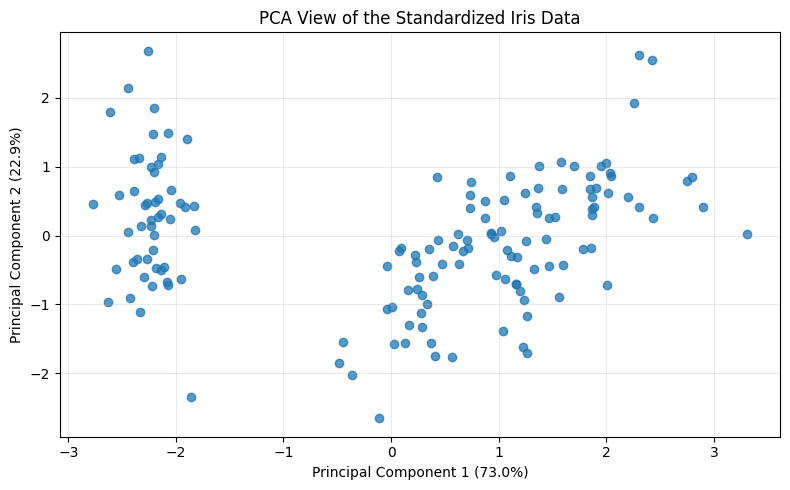

In [9]:
X_pca = X_pca_all[:, :2]

plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.75
)

plt.title("PCA View of the Standardized Iris Data")
plt.xlabel(f"Principal Component 1 ({variance[0]:.1f}%)")
plt.ylabel(f"Principal Component 2 ({variance[1]:.1f}%)")
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_pca_standardized_data.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 10. PCA Scree Plot

The scree plot shows how much variance each principal component explains individually.

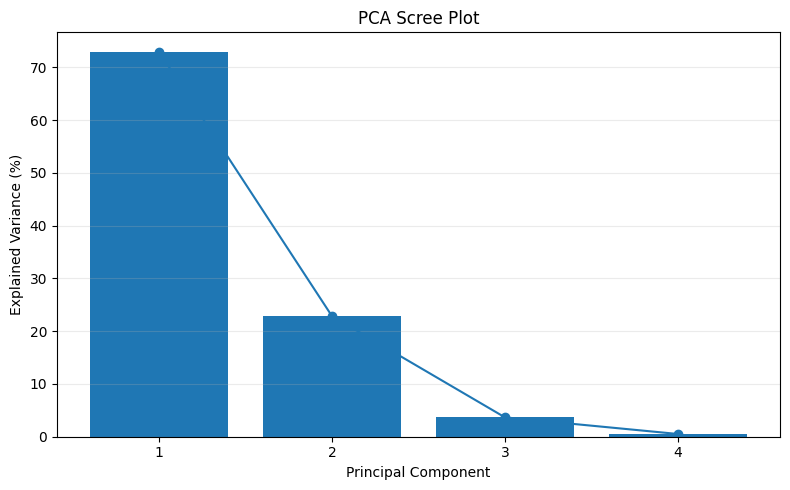

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    components,
    variance
)
plt.plot(
    components,
    variance,
    marker="o"
)

plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.xticks(components)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_pca_scree_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 11. PCA Cumulative Variance

The first two components explain approximately **95.81%** of the variance, so the 2D PCA visualization preserves most of the information contained in the four original features.

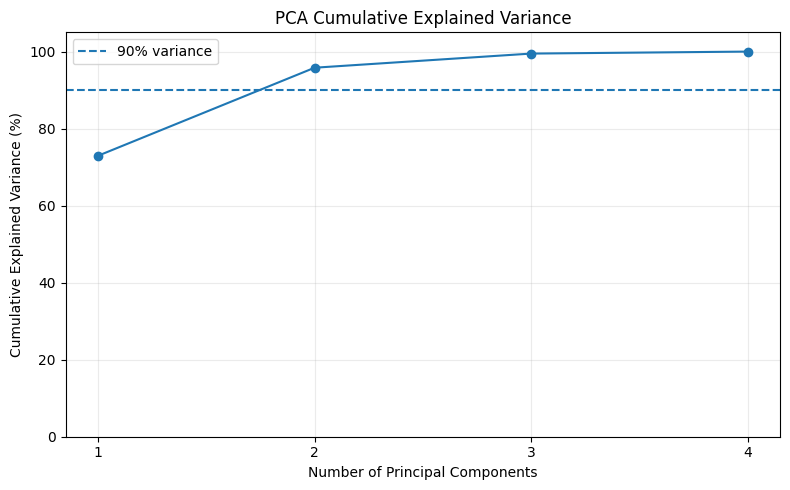

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    components,
    cumulative_variance,
    marker="o"
)
plt.axhline(
    90,
    linestyle="--",
    label="90% variance"
)

plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.xticks(components)
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_pca_cumulative_variance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Step 5 — Configure Hierarchical Clustering

## 12. Model Choice

This project uses:

- **Agglomerative clustering:** bottom-up clustering
- **Complete linkage:** distance between clusters is based on their farthest points
- **Euclidean distance:** straight-line distance between standardized observations

### Why Complete Linkage?

Complete linkage tends to form compact groups and reduces the chaining effect that can occur with single linkage.

Other common linkage choices include:

- Single / minimum linkage
- Average linkage
- Ward linkage

Ward linkage specifically requires Euclidean distance.

## 13. Test k = 2 Through k = 7

For each integer value of k, calculate:

- Silhouette Score
- Davies–Bouldin Index
- WCSS

Hierarchical clustering does not provide an `inertia_` attribute, so WCSS is calculated manually from each cluster's centroid.

In [12]:
k_values = list(range(2, 8))

labels_for_k = {}
silhouette_scores = []
davies_bouldin_scores = []
wcss_values = []

for k in k_values:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="complete",
        metric="euclidean"
    )

    labels = model.fit_predict(X_scaled)
    labels_for_k[k] = labels

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

    davies_bouldin_scores.append(
        davies_bouldin_score(X_scaled, labels)
    )

    wcss = 0.0

    for cluster_id in range(k):
        cluster_points = X_scaled[
            labels == cluster_id
        ]
        cluster_centroid = cluster_points.mean(axis=0)

        wcss += (
            (cluster_points - cluster_centroid) ** 2
        ).sum()

    wcss_values.append(wcss)

evaluation_results = pd.DataFrame({
    "k": k_values,
    "Silhouette Score": silhouette_scores,
    "Davies-Bouldin Index": davies_bouldin_scores,
    "WCSS": wcss_values,
})

display(evaluation_results.round(4))

,k,Silhouette Score,Davies-Bouldin Index,WCSS
0,2,0.4408,0.8927,296.3624
1,3,0.4496,0.7584,153.8828
2,4,0.4106,0.8768,125.5186
3,5,0.3521,0.8584,107.1906
4,6,0.3107,0.8824,99.8704
5,7,0.3076,0.7948,91.7728


## 14. Select the Final Number of Clusters

A good cluster solution should have:

- **Higher Silhouette Score**
- **Lower Davies–Bouldin Index**
- Reasonable WCSS improvement
- Visual support from the dendrogram and PCA plot

For this analysis, both the Silhouette Score and Davies–Bouldin Index select **k = 3**.

In [13]:
best_silhouette_k = int(
    evaluation_results.loc[
        evaluation_results["Silhouette Score"].idxmax(),
        "k"
    ]
)

best_davies_k = int(
    evaluation_results.loc[
        evaluation_results["Davies-Bouldin Index"].idxmin(),
        "k"
    ]
)

selected_k = 3

print("Best k from Silhouette Score:", best_silhouette_k)
print("Best k from Davies-Bouldin Index:", best_davies_k)
print("Final selected k:", selected_k)

Best k from Silhouette Score: 3
Best k from Davies-Bouldin Index: 3
Final selected k: 3


# Step 6 — Evaluate the Cluster Count

## 15. Hierarchical WCSS Plot

The red dashed line marks the selected value **k = 3**.

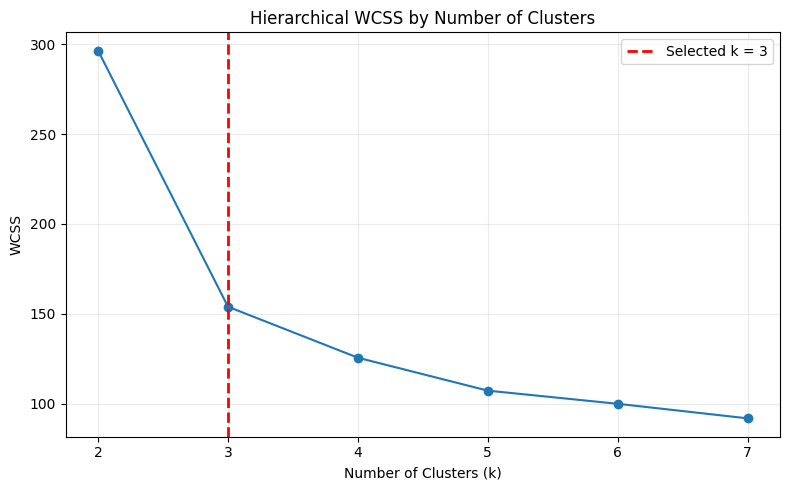

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss_values,
    marker="o"
)
plt.axvline(
    selected_k,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Selected k = {selected_k}"
)

plt.title("Hierarchical WCSS by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_hierarchical_wcss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 16. Silhouette Score Plot

Higher values indicate better separation between clusters.

The maximum score occurs at **k = 3**.

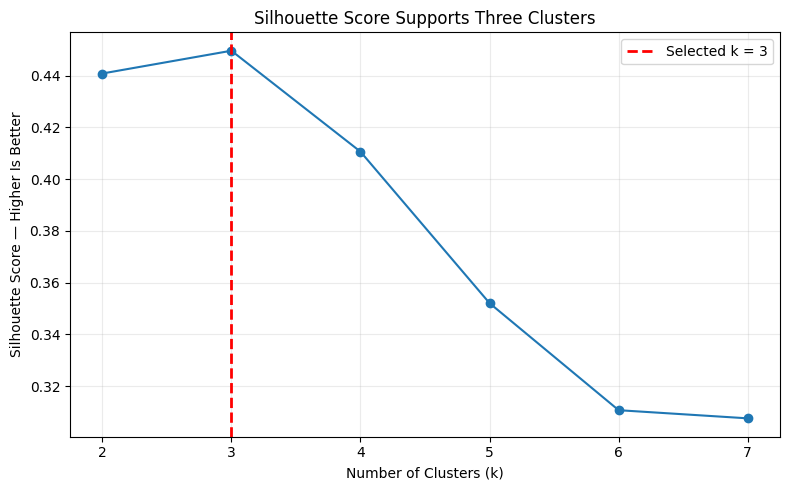

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)
plt.axvline(
    selected_k,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Selected k = {selected_k}"
)

plt.title("Silhouette Score Supports Three Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score — Higher Is Better")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_hierarchical_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 17. Davies–Bouldin Index Plot

Lower values indicate more compact and better-separated clusters.

The minimum Davies–Bouldin Index occurs at **k = 3**.

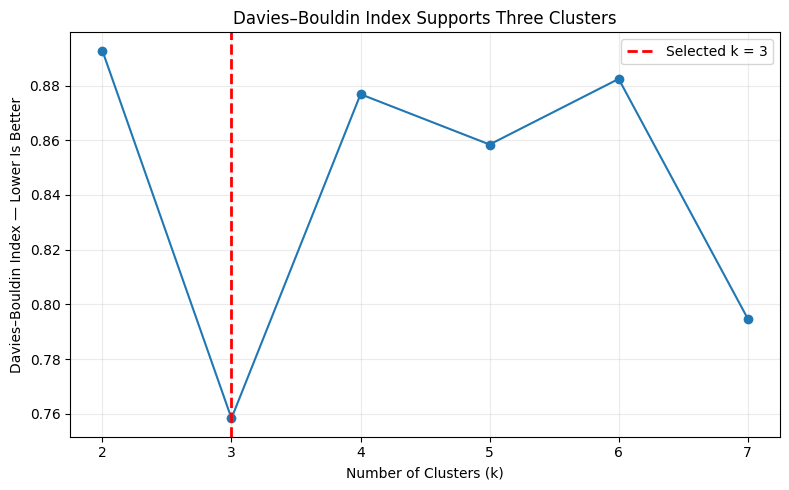

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    davies_bouldin_scores,
    marker="o"
)
plt.axvline(
    selected_k,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Selected k = {selected_k}"
)

plt.title("Davies–Bouldin Index Supports Three Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies–Bouldin Index — Lower Is Better")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_hierarchical_davies_bouldin.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Step 7 — Fit the Final Hierarchical Model

## 18. Create the Final Three Clusters

In [17]:
final_model = AgglomerativeClustering(
    n_clusters=selected_k,
    linkage="complete",
    metric="euclidean"
)

final_labels = final_model.fit_predict(X_scaled)

final_silhouette = silhouette_score(
    X_scaled,
    final_labels
)

final_davies_bouldin = davies_bouldin_score(
    X_scaled,
    final_labels
)

cluster_counts = (
    pd.Series(final_labels + 1, name="Cluster")
    .value_counts()
    .sort_index()
    .rename("Flower Count")
    .to_frame()
)

display(cluster_counts)

print(
    f"Final Silhouette Score: "
    f"{final_silhouette:.4f}"
)

print(
    f"Final Davies-Bouldin Index: "
    f"{final_davies_bouldin:.4f}"
)

,Flower Count
Cluster,
1,77
2,49
3,24


Final Silhouette Score: 0.4496
Final Davies-Bouldin Index: 0.7584


## 19. Profile the Final Clusters on the Original Measurement Scale

Cluster labels alone do not explain what makes each group different.

The following table compares the **average sepal and petal measurements** of each final cluster using the original centimeter scale.

In [18]:
cluster_profile = (
    X.assign(Cluster=final_labels + 1)
    .groupby("Cluster")
    .mean()
    .round(2)
)

display(cluster_profile)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Cluster,,,,
1,6.47,2.99,5.18,1.82
2,5.02,3.45,1.47,0.24
3,5.51,2.47,3.87,1.17


### Cluster Profile Interpretation

Using the actual mean measurements:

- **Cluster 2** contains flowers with the smallest petal measurements and relatively short sepals.
- **Cluster 1** contains flowers with the largest average sepal length and the largest petal measurements.
- **Cluster 3** falls between those two groups, especially for petal length and petal width.

This supports the PCA result: one group is clearly separated while the other two are closer together.

# Step 8 — Dendrogram

## 20. Build the Complete-Linkage Dendrogram

A red dashed horizontal cut is placed between the merge levels that produce exactly **three clusters**.

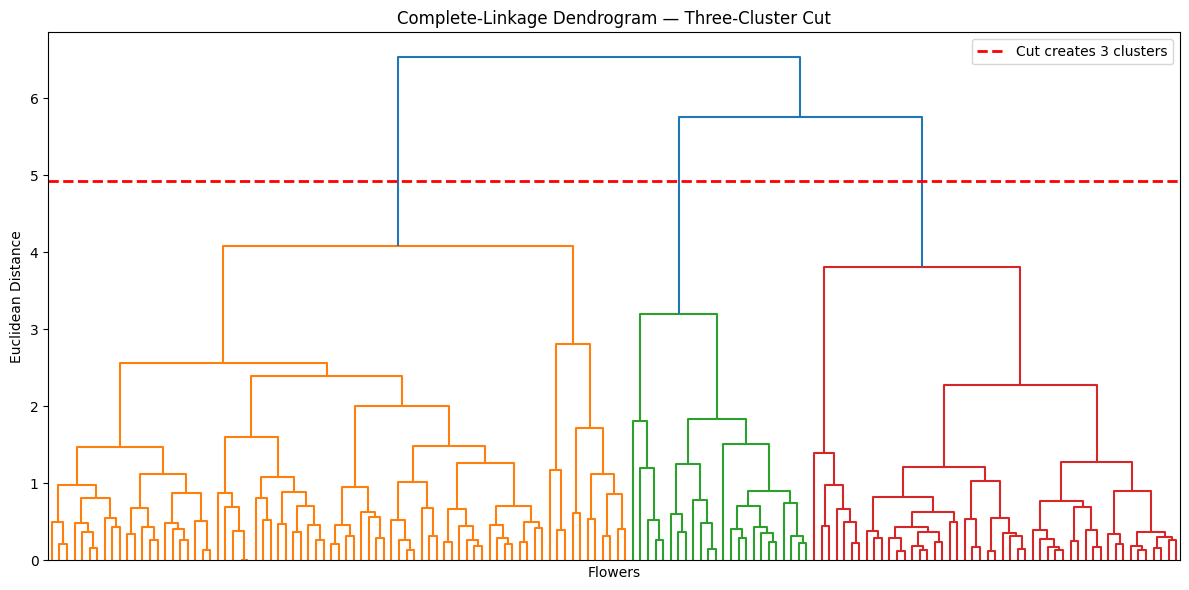

In [19]:
linkage_matrix = linkage(
    X_scaled,
    method="complete",
    metric="euclidean"
)

cut_height = (
    linkage_matrix[-selected_k, 2]
    + linkage_matrix[-selected_k + 1, 2]
) / 2

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    color_threshold=cut_height,
    no_labels=True
)

plt.axhline(
    cut_height,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Cut creates {selected_k} clusters"
)

plt.title("Complete-Linkage Dendrogram — Three-Cluster Cut")
plt.xlabel("Flowers")
plt.ylabel("Euclidean Distance")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "07_dendrogram_k3.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Step 9 — Visualize the Final Clusters with PCA

## 21. PCA Plot of the Three Hierarchical Clusters

The first two PCA components explain approximately **95.81%** of the total variance.

The plot shows:

- One clearly separated cluster
- Two clusters with some overlap

This agrees with the **moderate** Silhouette Score rather than suggesting perfect separation.

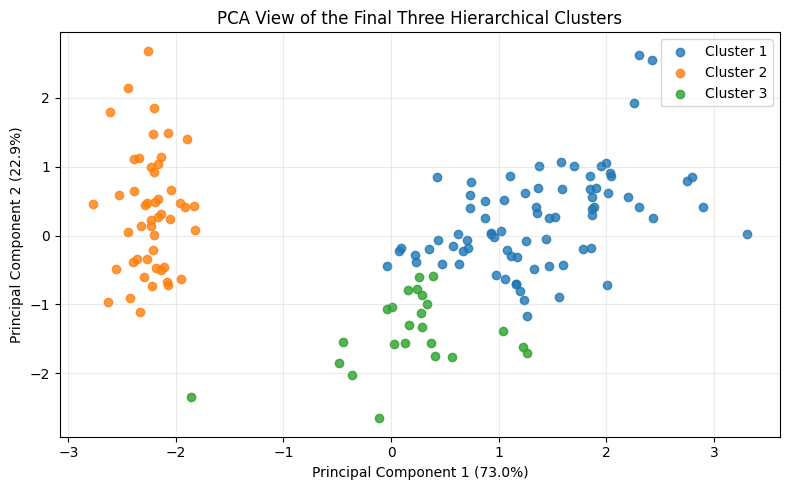

In [20]:
plt.figure(figsize=(8, 5))

for cluster_id in range(selected_k):
    plt.scatter(
        X_pca[final_labels == cluster_id, 0],
        X_pca[final_labels == cluster_id, 1],
        label=f"Cluster {cluster_id + 1}",
        alpha=0.8
    )

plt.title("PCA View of the Final Three Hierarchical Clusters")
plt.xlabel(f"Principal Component 1 ({variance[0]:.1f}%)")
plt.ylabel(f"Principal Component 2 ({variance[1]:.1f}%)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "08_hierarchical_pca_k3.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Step 10 — Final Interpretation

## Why k = 3?

The evidence supports **three clusters** because:

1. `k = 3` has the **highest Silhouette Score: 0.4496**.
2. `k = 3` has the **lowest Davies–Bouldin Index: 0.7584**.
3. The dendrogram can be cut into three branches at a clear merge height.
4. The PCA plot shows three visible groups.
5. PC1 and PC2 explain approximately **95.81%** of the original variance, so the 2D visual is highly informative.

## What Does the Silhouette Score Mean?

A score of 0.4496 indicates **moderate** separation.

The clusters are meaningful, but they are not perfectly isolated from one another. The PCA plot confirms this because two of the groups overlap.

## Why Complete Linkage?

Complete linkage uses the farthest pair of points when comparing clusters.

This discourages loose chain-like clusters and tends to create more compact groups than single linkage.

## Why Euclidean Distance?

Euclidean distance is appropriate for standardized continuous measurements and represents straight-line distance in feature space.

## Overall Conclusion

Hierarchical clustering successfully identifies three meaningful groups in the standardized Iris measurements. The strongest evidence comes from the agreement between the Silhouette Score, Davies–Bouldin Index, dendrogram, PCA visualization, and the original-scale cluster profiles.

# Limitations and Next Steps

## Limitations

- The Silhouette Score is moderate rather than extremely high, so some overlap remains.
- Hierarchical clustering is sensitive to the selected linkage rule and distance metric.
- The dendrogram becomes harder to interpret on much larger datasets.
- PCA is used only for visualization; it does not replace the four-feature clustering model.
- The known Iris species labels are excluded from model formation, as required for unsupervised clustering.

## Possible Extensions

- Compare complete linkage with single, average, and Ward linkage.
- Compare hierarchical clustering with K-Means.
- Use the known species labels only after clustering to assess external agreement.
- Test cluster stability under small perturbations of the data.